# Apply Stardist 2D Model on Local Image

This notebook demonstrates how to apply a Stardist 2D model on local image.

We start by importing the necessary Python libraries.

In [1]:
import numpy as np
from pathlib import Path
from stardist.models import StarDist2D
from csbdeep.utils import normalize
from skimage.io import imread, imsave, imshow

## 1. Opening Image

Then, we specify the path to the input image and store the file name.

In [2]:
image_path = Path(r"C:\Users\mazo260d\Desktop\blobs.tif")
file_name = image_path.stem

Now, we read the image as a numpy array and print its shape.

(254, 256)


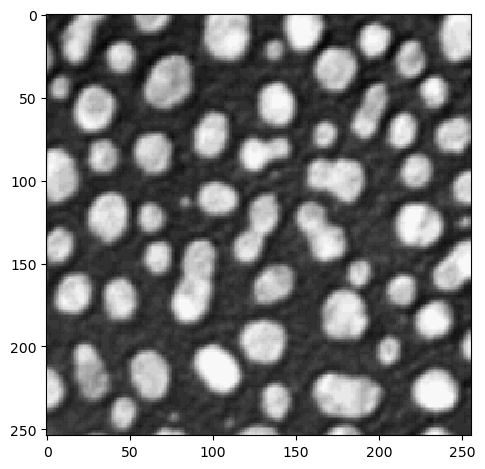

In [3]:
image = imread(image_path)
print(image.shape)
imshow(image)

## 2. Loading Pre-trained Model

Stardist has a few pre-trained models available. We will use the `2D_versatile_fluo` model in this notebook, selected from a list of available model names.

In [8]:
stardist_model_names = ['2D_versatile_fluo', '2D_versatile_he', '2D_paper_dsb2018']
chosen_model = stardist_model_names[0]
print("Chosen Model: ", chosen_model)
model = StarDist2D.from_pretrained(chosen_model)

Chosen Model:  2D_versatile_fluo
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


## 3. Running Predictions

We run the predictions on the image using the loaded model.

In [6]:
labels, _ = model.predict_instances(normalize(image))

1/1 [==============================] - 8s 8s/step


Number of Nuclei:  56


matplotlib_plugin.py (150): Low image data range; displaying image with stretched contrast.


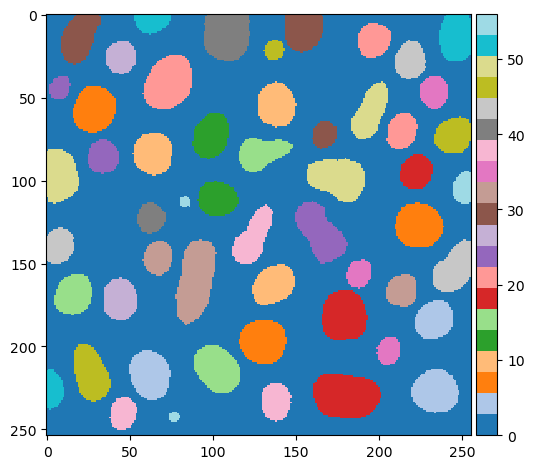

In [7]:
print("Number of Nuclei: ", labels.max())
imshow(labels, cmap='tab20')

## 4. Saving Outputs

Finally, we save the predicted label as '.tif' file.

In [9]:
label_image_name = file_name + "_label_" + chosen_model

In [10]:
output_path = image_path.parent / (label_image_name + ".tif")
imsave(output_path, labels)

C:\Users\mazo260d\Desktop\blobs_label_2D_versatile_fluo.tif


1707206441.py (3): C:\Users\mazo260d\Desktop\blobs_label_2D_versatile_fluo.tif is a low contrast image
